In [22]:
import pandas as pd
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

In [23]:
# В файле могут содержаться данные по покупкам нескольких акций, поэтому надо вывести их список, чтобы делать анализ в отдельности для каждый акции
file_path = r'/Users/daniil/Desktop/Отчеты/Акции.xlsx'

xls_file = pd.ExcelFile(file_path)
company_names : list = xls_file.sheet_names
print(company_names)  

['Сбер', 'Роснефть']


In [24]:
# Тестово настроим скрипт анализа на СБере, далее объединим данные в единый отчет
work_df : pd.DataFrame = pd.read_excel(file_path, sheet_name=company_names[0], usecols="A,B,C,D,E")
work_df.fillna(0, inplace=True)
work_df = work_df.rename(columns={'Дата' : 'date',
                                  'Кол-во' : 'cnt',
                                  'Общая цена' : 'all_pr',
                                  'Цена на акцию' : 'one_price',
                                  'Дивиденды' : 'profit_sh'
                                  })
work_df = work_df.sort_values("date")
work_df['running_max'] = work_df['one_price'].cummax()
work_df['drawdown'] = (work_df['one_price'] - work_df['running_max']) / work_df['running_max'] * 100
work_df["mean_expanding"] = work_df["one_price"].expanding().mean()

work_df

,date,cnt,all_pr,one_price,profit_sh,running_max,drawdown,mean_expanding
0,2025-08-01,1,302.83,302.83,0.0,302.83,0.000000,302.830000
1,2025-08-04,1,302.81,302.81,0.0,302.83,-0.006604,302.820000
2,2025-08-05,1,304.10,304.10,0.0,304.10,0.000000,303.246667
3,2025-08-06,1,303.72,303.72,0.0,304.10,-0.124959,303.365000
4,2025-08-07,1,310.32,310.32,0.0,310.32,0.000000,304.756000
...,...,...,...,...,...,...,...,...
115,2026-02-07,1,302.11,302.11,0.0,317.40,-4.817265,300.476622
116,2026-02-09,1,301.46,301.46,0.0,317.40,-5.022054,300.485027
117,2026-02-10,1,303.03,303.03,0.0,317.40,-4.527410,300.506595
118,2026-02-11,1,303.85,303.85,0.0,317.40,-4.269061,300.534691


In [4]:
work_df.dtypes

date           datetime64[us]
cnt                     int64
all_pr                float64
one_price             float64
profit_sh             float64
running_max           float64
drawdown              float64
dtype: object

In [20]:
# Описание выборки
print(f"Всего куплено акций за период: {work_df.shape[0]}")
print(f"Дата первой покупки: {work_df.date.dt.date.min()}")
print(f"Дата последней покупки: {work_df.date.dt.date.max()}")
print(f"Затраченная сумма на покупку: {work_df.all_pr.sum():_.2f}".replace('_', ' '))

Всего куплено акций за период: 120
Дата первой покупки: 2025-08-01
Дата последней покупки: 2026-02-12
Затраченная сумма на покупку: 39 097.94


In [ ]:
#агрегирующие значения
count_sh : int = work_df.cnt.sum()
mean_cost : float = work_df.one_price.mean().round(2)
median_cost : float = work_df.one_price.median().round(2)
diff_avg_values : float = round(mean_cost / median_cost - 1, 3)*100
all_sum_buy : float = work_df.all_pr.sum().round(2)
weighted_mean_price : float = sum(work_df.cnt * work_df.one_price) / work_df.cnt.sum()
# Коэффициент DCA-эффективности
# Показывает, насколько хорошо сработала стратегия усреднения — насколько средневзвешенная цена ниже средней цены рынка за период:
dca_efficiency = (mean_cost - weighted_mean_price) / mean_cost * 100
# Процент “удачных” покупок
# Доля покупок ниже средневзвешенной цены (дешевле, чем средняя себестоимость):
pct_below_wm = (work_df['one_price'] < weighted_mean_price).mean() * 100 
# максимальное падение цены от пика
# берёт наибольшее по модулю отрицательное значение — это и есть worst-case: в какой момент ты купил акцию, 
# а она была максимально далека от своего пика на тот момент. 
# В твоём портфеле Сбера цена падала с 317.4 ₽ до 281.45 ₽ — это просадка ~−11.3% от пика закупочных цен.
max_drawdown = work_df['drawdown'].min()  
# Результат от −1 до +1:
# 	•	+1 — если цена была высокой, следующая тоже высокая (инерция/тренд)
# 	•	0 — нет связи (случайный процесс)
# 	•	−1 — после высокой всегда следует низкая (осцилляция)
acf_1 = work_df['one_price'].autocorr(lag=1)


print(f"Общее кол-во купленных акций: {count_sh}. \nСредняя цена покупки {mean_cost}. \nСредневзвешенная цена покупки (точка безубыточности) {weighted_mean_price.round(2)}. \nМедиальная цена покупки {median_cost}. \nОбщая сумма покупки: {all_sum_buy}")
print(f"Коэффициент DCA-эффективности: {dca_efficiency:.2f}, \nМаксимальное падение цены от пика: {max_drawdown:.2f}, \nПроцент 'удачных' покупок: {pct_below_wm:.2f}")

print('\n' + '=' * 10)
print(f'Разница между средним и медианой цены акций: {diff_avg_values}%')
print('Оценка разницы:')
if diff_avg_values <= 5:
    print('    - Очень стабильная стратегия покупки акциий')
elif diff_avg_values > 5 and diff_avg_values <= 10:
    print('    - Стабильная стратегия покупки акций')
elif diff_avg_values > 10 and diff_avg_values <= 25:
    print('    - Есть дисбаланс в объемах: были крупные покупки по ценам, отличным от средних')
else:
    print('    - Стратегия требует пересмотра, значительная часть капитала вложена по невыгодным ценам')

Общее кол-во купленных акций: 130. 
Средняя цена покупки 300.58. 
Средневзвешенная цена покупки (точка безубыточности) 300.75. 
Медиальная цена покупки 301.28. 
Общая сумма покупки: 39097.94
Коэффициент DCA-эффективности: -0.06, 
Максимальное падение цены от пика: -11.33, 
Процент 'удачных' покупок: 45.00

Разница между средним и медианой цены акций: -0.2%
Оценка разницы:
    - Очень стабильная стратегия покупки акциий


### Изучаем распределение на нормальность

/var/folders/jd/h6xbmqvn231_8h53brhm08240000gn/T/ipykernel_22118/3351657657.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()


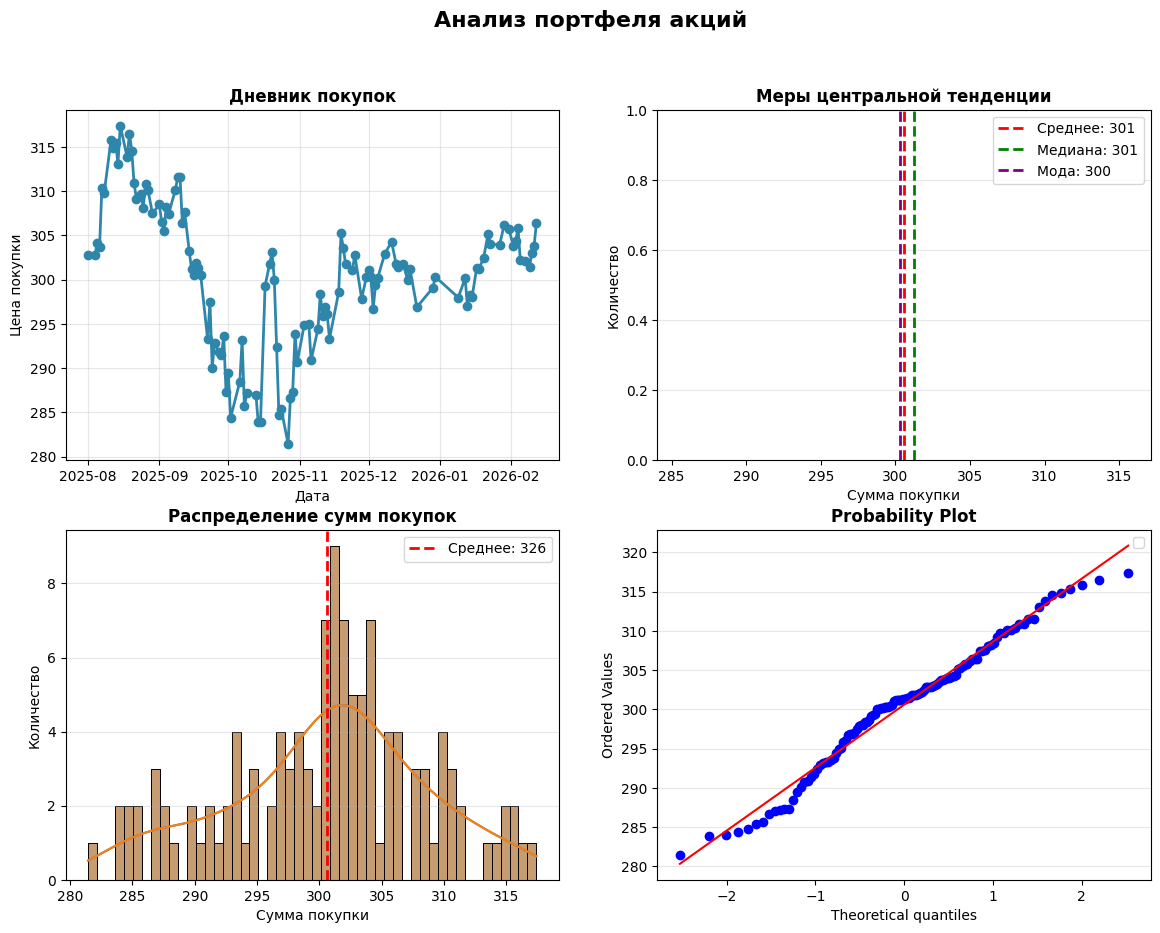

In [57]:
fig_1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_1.suptitle('Анализ портфеля акций', fontsize=16, fontweight='bold')

axes[0, 0].plot(work_df.date, work_df.one_price, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].set_title('Дневник покупок', fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Цена покупки')
axes[0, 0].grid(True, alpha=0.3)


# 1. Считаем метрики
mean_val = work_df['one_price'].mean()     # Среднее
median_val = work_df['one_price'].median() # Медиана
# Мода (берем первое значение, так как моды может быть несколько)
mode_val = work_df['one_price'].mode()[0]  

sns.histplot(data=work_df, x='one_price', bins=50, kde=True, ax=axes[1, 0])
axes[0, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:,.0f}')
axes[0, 1].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:,.0f}')
axes[0, 1].axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f'Мода: {mode_val:,.0f}')
axes[0, 1].set_title('Меры центральной тенденции', fontweight='bold')
axes[0, 1].set_xlabel('Сумма покупки')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].legend() # Легенда отобразит все 3 метрики
axes[0, 1].grid(True, alpha=0.3, axis='y')


sns.histplot(data=work_df, x='one_price', bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].axvline(work_df.one_price.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {work_df.all_pr.mean():,.0f}')
axes[1, 0].set_title('Распределение сумм покупок', fontweight='bold')
axes[1, 0].set_xlabel('Сумма покупки')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

stats.probplot(work_df.one_price, dist="norm", plot=plt)
axes[1, 1].set_title('Probability Plot', fontweight='bold')
axes[1, 1].set_xlabel('Theoretical quantiles')
axes[1, 1].set_ylabel('Ordered Values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
# # 4. Дивиденды во времени

In [54]:
# 1. Считаем метрики
mean_val = work_df['one_price'].mean()     # Среднее
median_val = work_df['one_price'].median() # Медиана
# Мода (берем первое значение, так как моды может быть несколько)
mode_val = work_df['one_price'].mode()[0]  

# 2. Строим сам график
sns.histplot(data=work_df, x='one_price', bins=50, kde=True, ax=axes[1, 0])

# 3. Добавляем вертикальные линии для каждой метрики
# Среднее (Красный пунктир)
axes[1, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {mean_val:,.0f}')

# Медиана (Зеленый пунктир)
axes[1, 0].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                   label=f'Медиана: {median_val:,.0f}')

# Мода (Фиолетовый пунктир)
axes[1, 0].axvline(mode_val, color='purple', linestyle='--', linewidth=2, 
                   label=f'Мода: {mode_val:,.0f}')

# 4. Настраиваем легенду и подписи
axes[1, 0].set_title('Распределение сумм покупок', fontweight='bold')
axes[1, 0].set_xlabel('Сумма покупки')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend() # Легенда отобразит все 3 метрики
axes[1, 0].grid(True, alpha=0.3, axis='y')



In [12]:
#Шапиро–Уилка (для небольших выборок, до ~5000)
# Интерпретация:
# 	p > 0.05  → нет оснований говорить, что распределение не нормальное
# 	p ≤ 0.05  → статистически значимое отклонение от нормальности.

stat, p = stats.shapiro(work_df.one_price)
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}")

Shapiro-Wilk: stat=0.9800, p=0.0717


In [13]:
# Колмогоров–Смирнов (для сравнения с нормой)
# Нормируем данные
# stat  — это статистика Колмогорова–Смирнова (максимальное расстояние между эмпирической и теоретической CDF). Чем она больше, тем сильнее твои данные отличаются от нормального распределения.
# p  — вероятность получить такое (или более экстремальное) значение статистики  stat , если на самом деле данные нормальны.

# Дальше:
# 	Если  p < 0.05  (или выбранный тобой уровень значимостиы), отвергаем H0: «распределение соответствует нормальному». Говорим: «есть статистически значимые отличия от нормали, распределение не нормальное».
# 	Если  p ≥ 0.05, нет оснований отвергать H0. Говорим аккуратно: «значимых отличий от нормального распределения не найдено, данные совместимы с нормальностью».


data_std = (work_df.one_price - np.mean(work_df.one_price)) / np.std(work_df.one_price, ddof=1)

stat, p = stats.kstest(data_std, 'norm')
print(f"KS: stat={stat:.4f}, p={p:.4f}")

KS: stat=0.0949, p=0.2161


### Динамика накоплений акций

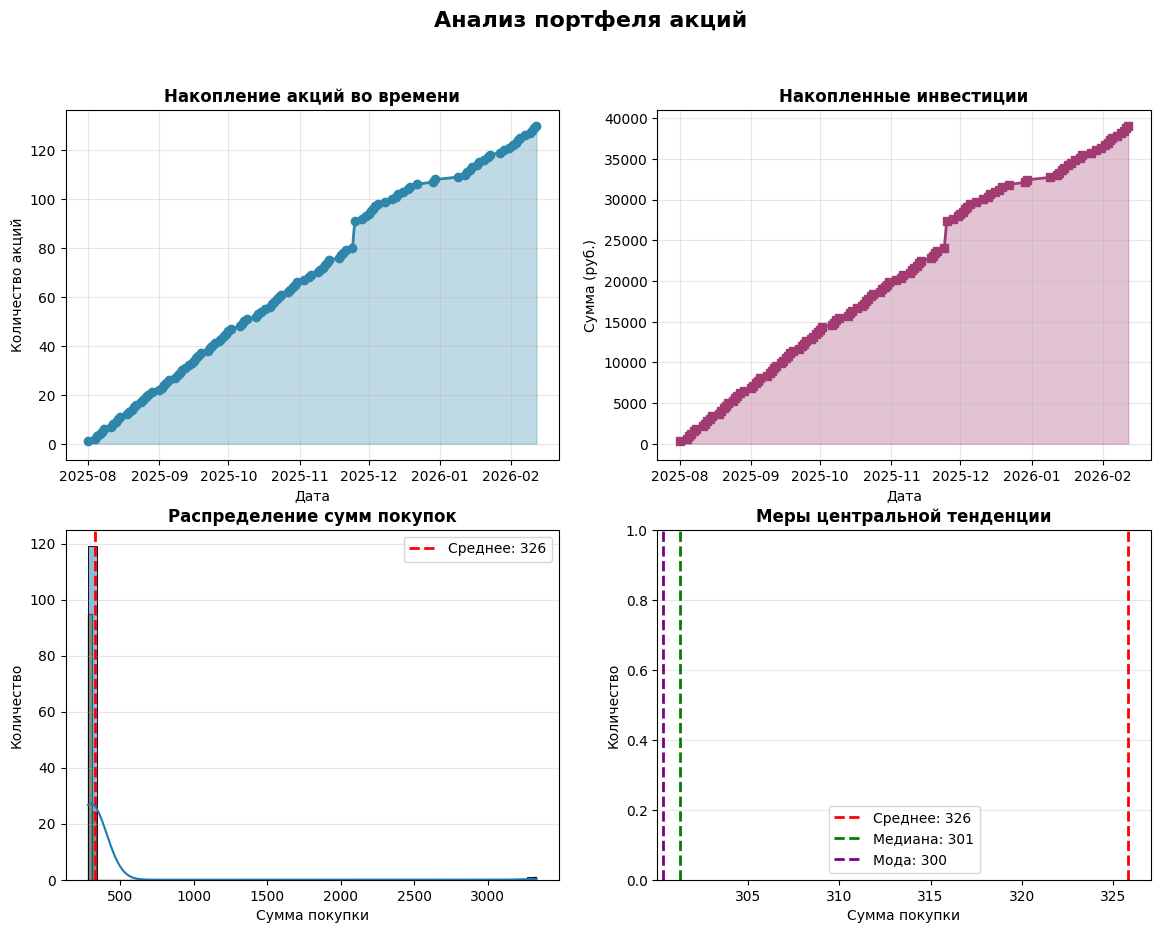

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ портфеля акций', fontsize=16, fontweight='bold')

# 1. Динамика накопления акций
work_df['Накоплено акций'] = work_df.cnt.cumsum()
work_df['Накопленные инвестиции'] = work_df.all_pr.cumsum()

axes[0, 0].plot(work_df.date, work_df['Накоплено акций'], marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].fill_between(work_df.date, work_df['Накоплено акций'], alpha=0.3, color='#2E86AB')
axes[0, 0].set_title('Накопление акций во времени', fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество акций')
axes[0, 0].grid(True, alpha=0.3)

# 2. Динамика инвестиций
axes[0, 1].plot(work_df.date, work_df['Накопленные инвестиции'], marker='s', linewidth=2, color='#A23B72')
axes[0, 1].fill_between(work_df.date, work_df['Накопленные инвестиции'], alpha=0.3, color='#A23B72')
axes[0, 1].set_title('Накопленные инвестиции', fontweight='bold')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Сумма (руб.)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение сумм покупок по средневзвешенному
axes[1, 0].hist(work_df.all_pr, bins=work_df.shape[0], edgecolor='black', color='#F18F01', alpha=0.7)
axes[1, 0].axvline(work_df.all_pr.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {work_df.all_pr.mean():,.0f}')
axes[1, 0].set_title('Распределение сумм покупок', fontweight='bold')
axes[1, 0].set_xlabel('Сумма покупки')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')



# 3. Распределение сумм среднего
# 1. Считаем метрики
mean_val = work_df['all_pr'].mean()     # Среднее
median_val = work_df['all_pr'].median() # Медиана
# Мода (берем первое значение, так как моды может быть несколько)
mode_val = work_df['all_pr'].mode()[0]  

sns.histplot(data=work_df, x='all_pr', bins=50, kde=True, ax=axes[1, 0])
axes[1, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:,.0f}')
axes[1, 1].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:,.0f}')
axes[1, 1].axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f'Мода: {mode_val:,.0f}')
axes[1, 1].set_title('Меры центральной тенденции', fontweight='bold')
axes[1, 1].set_xlabel('Сумма покупки')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].legend() # Легенда отобразит все 3 метрики
axes[1, 1].grid(True, alpha=0.3, axis='y')

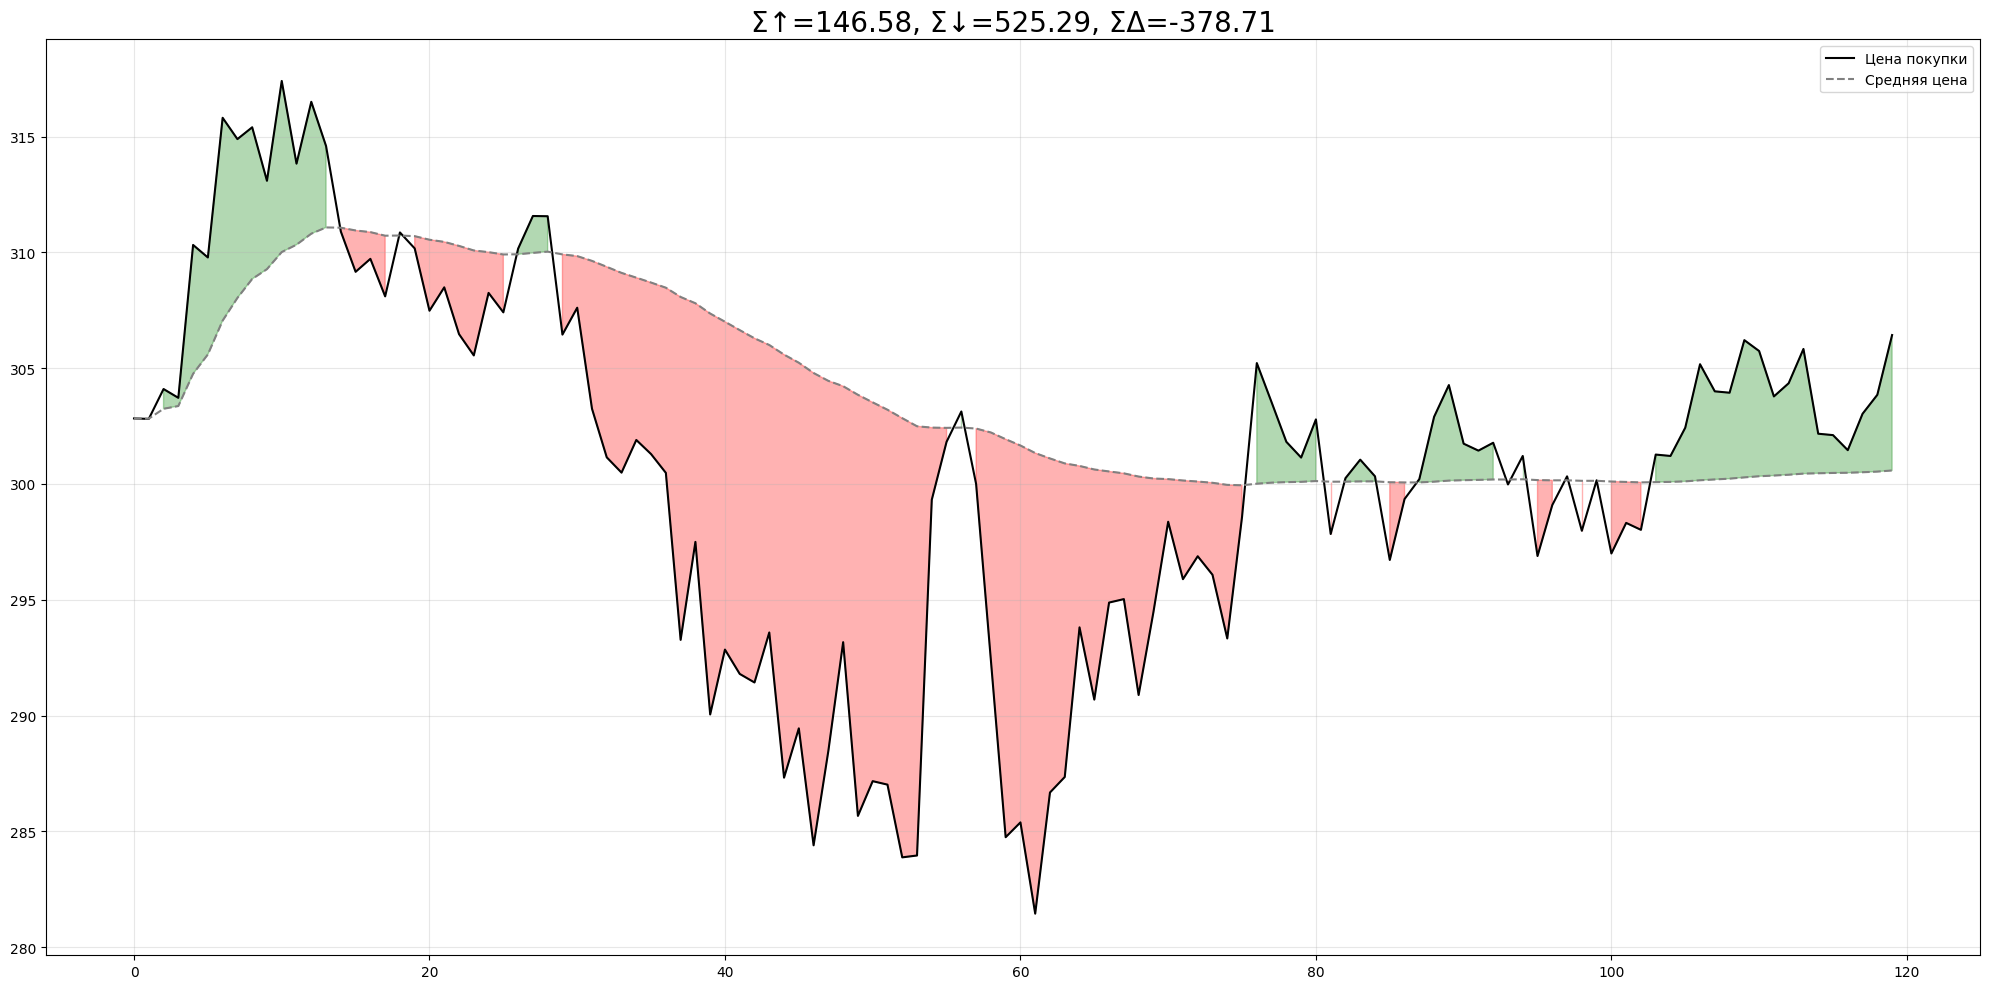

In [36]:
price = work_df["one_price"]
avg   = work_df["mean_expanding"]

# маски
above = price > avg
below = price < avg

# суммы отклонений
sum_above = (price[above] - avg[above]).sum()
sum_below = (avg[below] - price[below]).sum()
sum_abs   = (price - avg).sum()  # «полная площадь» между линиями

fig, ax = plt.subplots(figsize=(20, 10))

x = work_df.index

ax.plot(x, price, label="Цена покупки", color="black", linewidth=1.5)
ax.plot(x, avg,   label="Средняя цена", color="gray", linestyle="--")

ax.fill_between(x, price, avg, where=above, color="green", alpha=0.3)
ax.fill_between(x, price, avg, where=below, color="red",   alpha=0.3)

# можно вынести суммы в заголовок
ax.set_title(
    f"Σ↑={sum_above:.2f}, Σ↓={sum_below:.2f}, ΣΔ={sum_abs:.2f}", fontsize = 20
)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Что лучше считать
Для более корректной оценки я бы смотрел не только на закрашенную площадь, но и на 4 метрики: финальное отклонение от средней цены, долю дней ниже средней, максимальную просадку относительно средней и время восстановления до выхода выше средней. Если это именно покупки частями, то ещё важнее считать PnL с весами по объёму сделок, потому что визуальная площадь между линиями сама по себе не равна реальной прибыли или убытку.
Практический вывод
В текущем виде график больше похож на позицию с тяжёлой промежуточной просадкой и поздним улучшением, чем на удачно таймированный вход. Для реальной оценки стратегии я бы добавил на график точки сделок, объёмы покупок и отдельно вывел  max drawdown ,  days below avg  и  current edge = last_price - avg_price .
Могу сразу дать тебе код на pandas/matplotlib, который поверх такого графика посчитает эти 3–4 метрики и подпишет их прямо на рисунке.


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# df.index -> datetime
# df.columns -> ["price", "avg_price"]

price = work_df["one_price"]
avg = work_df["mean_expanding"]

# отклонения
diff = price - avg
rel_diff_pct = (price / avg - 1) * 100

# области
above = price > avg
below = price < avg

# 1) финальное отклонение от средней
final_edge_abs = diff.iloc[-1]
final_edge_pct = rel_diff_pct.iloc[-1]

# 2) доля точек ниже средней
# если у тебя одна строка = один день, это и будет доля дней
pct_below = below.mean() * 100

# 3) максимальная просадка относительно средней
# абсолютная и относительная
max_dd_abs = diff.min()
max_dd_pct = rel_diff_pct.min()
trough_date = diff.date.dt.min()

# 4) время восстановления: от даты максимальной просадки
# до первой даты, когда price снова >= avg
after_trough = work_df.loc[trough_date:]
recovery_candidates = after_trough.date[after_trough["one_price"] >= after_trough["mean_expanding"]]

if len(recovery_candidates) > 0:
    recovery_date = recovery_candidates.min()
    recovery_days = (recovery_date - trough_date).days
    recovery_text = f"{recovery_days} дн. до {recovery_date:%Y-%m-%d}"
else:
    recovery_text = "ещё не восстановилась"

# дополнительные суммы по закрашенным областям
sum_above = diff.clip(lower=0).sum()
sum_below = (-diff.clip(upper=0)).sum()
sum_signed = diff.sum()
sum_abs = diff.abs().sum()

fig, ax = plt.subplots(figsize=(12, 6))

x = work_df.index

# линии
ax.plot(x, price, label="Цена покупки", color="black", linewidth=1.5)
ax.plot(x, avg, label="Средняя цена", color="gray", linestyle="--", linewidth=1.2)

# заливки
ax.fill_between(
    x, price, avg,
    where=above,
    interpolate=True,
    color="green",
    alpha=0.28
)

ax.fill_between(
    x, price, avg,
    where=below,
    interpolate=True,
    color="red",
    alpha=0.28
)

# текстовый блок с метриками
metrics_text = (
    f"Финальное отклонение: {final_edge_abs:+.2f} ({final_edge_pct:+.2f}%)\n"
    f"Доля точек ниже средней: {pct_below:.1f}%\n"
    f"Макс. просадка к средней: {max_dd_abs:.2f} ({max_dd_pct:.2f}%)\n"
    f"Восстановление после минимума: {recovery_text}\n"
    f"Σ↑: {sum_above:.2f} | Σ↓: {sum_below:.2f}\n"
    f"ΣΔ: {sum_signed:+.2f} | Σ|Δ|: {sum_abs:.2f}"
)

ax.text(
    0.02, 0.98, metrics_text,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.9
    )
)

# отметка точки максимальной просадки
ax.scatter(
    trough_date,
    price.loc[trough_date],
    color="firebrick",
    s=40,
    zorder=5
)

ax.annotate(
    f"Макс. просадка\n{trough_date:%Y-%m-%d}",
    xy=(trough_date, price.loc[trough_date]),
    xytext=(20, -35),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#fff5f5",
        edgecolor="firebrick",
        alpha=0.95
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="firebrick",
        lw=1.2
    )
)

ax.set_title("Цена покупки и средняя цена")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


AttributeError: 'Series' object has no attribute 'date'